In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Reveal categories found in data.csv')

In [3]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
95,s96,TV Show,The Circle,NaN,Michelle Buteau,"United States, United Kingdom","September 8, 2021",2021,TV-MA,3 Seasons,Reality TV,Status and strategy collide in this social exp...
96,s97,Movie,If I Leave Here Tomorrow: A Film About Lynyrd ...,Stephen Kijak,"Ronnie Van Zandt, Gary Rossington, Allen Colli...",United States,"September 7, 2021",2018,TV-MA,97 min,"Documentaries, Music & Musicals","Using interviews and archival footage, this do..."
97,s98,TV Show,Kid Cosmic,NaN,"Jack Fisher, Tom Kenny, Amanda C. Miller, Kim ...",United States,"September 7, 2021",2021,TV-Y7,2 Seasons,"Kids' TV, TV Comedies, TV Sci-Fi & Fantasy",A boy's superhero dreams come true when he fin...
98,s99,TV Show,Octonauts: Above & Beyond,NaN,"Antonio Aakeel, Chipo Chung, Simon Foster, Ter...",United Kingdom,"September 7, 2021",2021,TV-Y,1 Season,"British TV Shows, Kids' TV",The Octonauts expand their exploration beyond ...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       100 non-null    object
 1   type          100 non-null    object
 2   title         100 non-null    object
 3   director      62 non-null     object
 4   cast          89 non-null     object
 5   country       60 non-null     object
 6   date_added    100 non-null    object
 7   release_year  100 non-null    int64 
 8   rating        100 non-null    object
 9   duration      100 non-null    object
 10  listed_in     100 non-null    object
 11  description   100 non-null    object
dtypes: int64(1), object(11)
memory usage: 9.5+ KB


In [8]:
import nltk
nltk.download('stopwords', 'wordnet', 'omw-1.4')

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [13]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [9]:
df['cast'] = df['cast'].fillna('Unknown')

In [10]:
df['country'] = df['country'].fillna('Unknown')

In [11]:
df['director'] = df['director'].fillna('Unknown')

In [12]:
df.isna().sum().sum()

np.int64(0)

In [14]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
  text = text.lower()

  text = re.sub(r'[^a-z\s]', '', text)

  words = text.split()

  cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

  return " ".join(cleaned_words)

In [15]:
df['clean_description'] = df['description'].apply(preprocess_text)

In [16]:
print(df['description'].head(3).values)

['As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.'
 'After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.'
 'To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war.']


In [17]:
print(df['clean_description'].head(3).values)

['father nears end life filmmaker kirsten johnson stage death inventive comical way help face inevitable'
 'crossing path party cape town teen set prove whether privateschool swimming star sister abducted birth'
 'protect family powerful drug lord skilled thief mehdi expert team robber pulled violent deadly turf war']


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
tfidf = tfidf_vectorizer = TfidfVectorizer(
    max_df=0.90,
    min_df=2,
    stop_words='english'
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_description'])

print(tfidf_matrix.shape)

(100, 188)


In [25]:
X_tfidf = tfidf.fit_transform(df['clean_description'])

In [27]:
X_tfidf.shape

(100, 188)

In [20]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print(feature_names[:20])

['accused' 'adolescent' 'adventure' 'america' 'amity' 'answer' 'archival'
 'attack' 'awakened' 'baker' 'based' 'battle' 'bear' 'begin' 'best' 'big'
 'bird' 'bond' 'boy' 'brody']


In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [26]:
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_tfidf)

  wcss.append(kmeans.inertia_)

  score = silhouette_score(X_tfidf, kmeans.labels_)
  silhouette_scores.append(score)

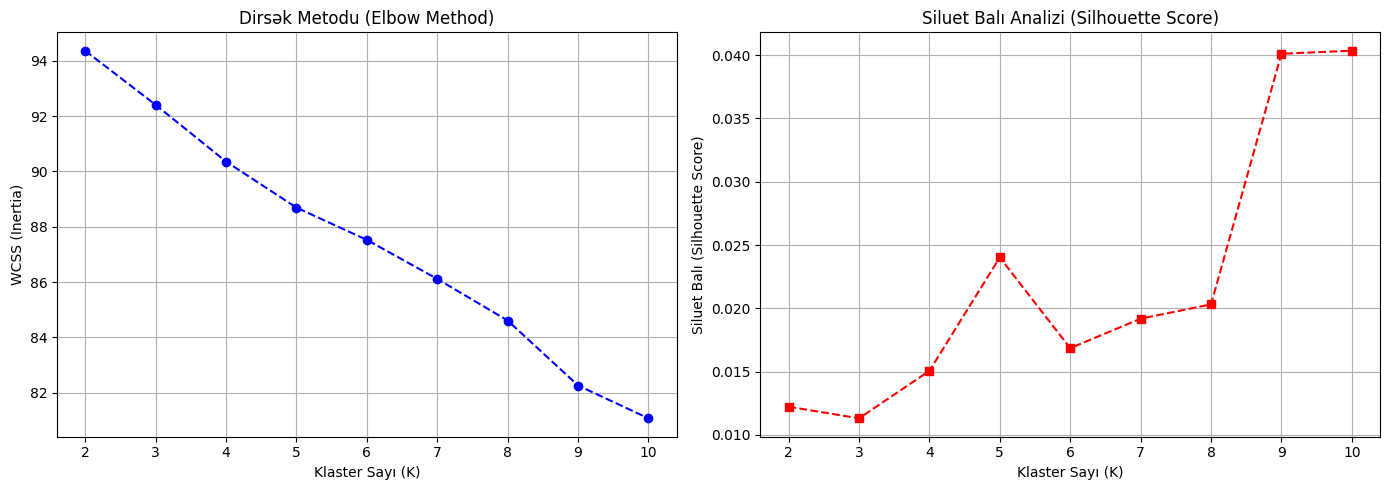

In [28]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o', color='b', linestyle='--')
plt.title('Dirsək Metodu (Elbow Method)')
plt.xlabel('Klaster Sayı (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='s', color='r', linestyle='--')
plt.title('Siluet Balı Analizi (Silhouette Score)')
plt.xlabel('Klaster Sayı (K)')
plt.ylabel('Siluet Balı (Silhouette Score)')
plt.xticks(k_range)
plt.grid(True)

plt.tight_layout()
plt.show()

In [30]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

kmeans.fit(X_tfidf)

df['cluster_label'] = kmeans.labels_

df['cluster_label'].value_counts()

,count
cluster_label,
1,57
3,16
2,14
0,13


In [38]:
terms = tfidf.get_feature_names_out()

order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(optimal_k):
    print(f"Klaster {i}:")

    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print("Açar sözlər:", ", ".join(top_words))

    sample_movies = df[df['cluster_label'] == i][['title', 'listed_in']].head(3)
    for idx, row in sample_movies.iterrows():
        print(f" - {row['title']} | Orijinal Janr: {row['listed_in']}")

Klaster 0:
Açar sözlər: ninja, naruto, missing, save, adventure, mission, protecting, sakura, fellow, adolescent
 - The Father Who Moves Mountains | Orijinal Janr: Dramas, International Movies, Thrillers
 - Chhota Bheem | Orijinal Janr: Kids' TV
 - Naruto Shippuden the Movie: Blood Prison | Orijinal Janr: Action & Adventure, Anime Features, International Movies
Klaster 1:
Açar sözlər: young, home, group, deadly, great, shark, justice, family, prove, power
 - Blood & Water | Orijinal Janr: International TV Shows, TV Dramas, TV Mysteries
 - Ganglands | Orijinal Janr: Crime TV Shows, International TV Shows, TV Action & Adventure
 - Midnight Mass | Orijinal Janr: TV Dramas, TV Horror, TV Mysteries
Klaster 2:
Açar sözlər: love, life, world, woman, big, help, city, tale, way, man
 - Dick Johnson Is Dead | Orijinal Janr: Documentaries
 - The Starling | Orijinal Janr: Comedies, Dramas
 - Dear White People | Orijinal Janr: TV Comedies, TV Dramas
Klaster 3:
Açar sözlər: new, friend, school, enem

In [39]:
from sklearn.decomposition import PCA

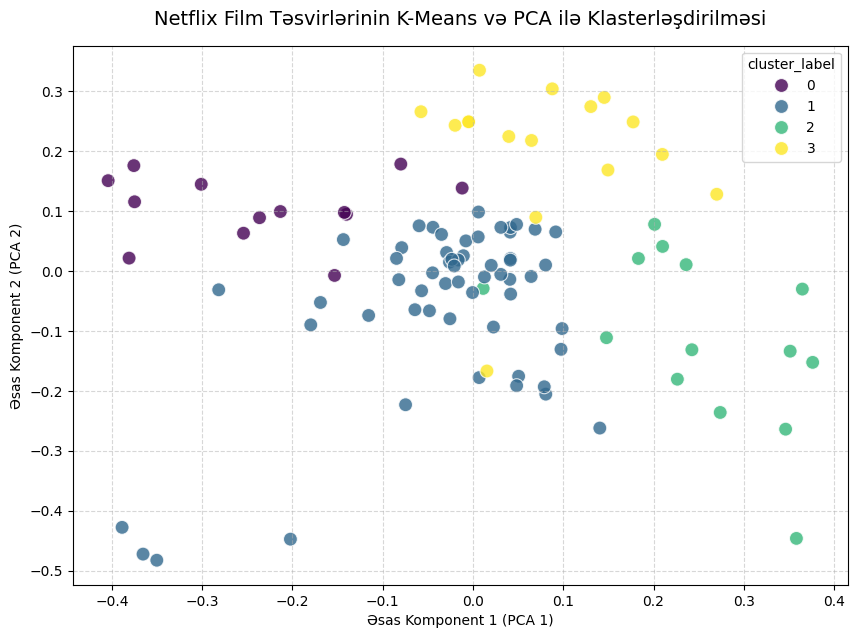

In [40]:
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_tfidf.toarray())

df['pca_x'] = X_pca[:, 0]
df['pca_y'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='pca_x', y='pca_y',
    hue='cluster_label',
    palette='viridis',
    data=df,
    legend='full',
    alpha=0.8,
    s=100
)

plt.title('Netflix Film Təsvirlərinin K-Means və PCA ilə Klasterləşdirilməsi', fontsize=14, pad=15)
plt.xlabel('Əsas Komponent 1 (PCA 1)')
plt.ylabel('Əsas Komponent 2 (PCA 2)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()